In [16]:
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import math
import pandas as pd

sys.path.append('../features')
from data_cleaner import DataCleaner

sns.set_theme(style="whitegrid", palette="muted")

In [3]:
cleaner = DataCleaner('../data/diem_thi_THPTQG_2026.csv')

df_raw = cleaner.load_data()

df_flagged = cleaner.score_under_1()

dict_blocks = cleaner.split_by_block()

df_A00 = dict_blocks['A00']
df_A00.head()

Eplore 581 students under 1 point!
Block A00: extracted 163276 valid students
Block A01: extracted 136860 valid students
Block A02: extracted 3331 valid students
Block A03: extracted 32513 valid students
Block A04: extracted 6718 valid students
Block A05: extracted 5683 valid students
Block A06: extracted 774 valid students
Block A07: extracted 248976 valid students
Block A08: extracted 111005 valid students
Block A09: extracted 96014 valid students
Block A10: extracted 5890 valid students
Block A11: extracted 763 valid students
Block B00: extracted 42523 valid students
Block B01: extracted 3331 valid students
Block B02: extracted 702 valid students
Block B03: extracted 59685 valid students
Block B04: extracted 579 valid students
Block B05: extracted 3146 valid students
Block C00: extracted 259525 valid students
Block C01: extracted 352447 valid students
Block C02: extracted 224353 valid students
Block C03: extracted 514860 valid students
Block C04: extracted 404827 valid students
Bloc

,SBD,Tỉnh,Toán,Văn,Lý,Hóa,Sinh,Sử,Địa,GD Kinh tế - Pháp luật,Tin học,Công nghệ,Ngoại ngữ,score_under_1,Total_A00
2,01000003,Hà Nội,6.50,7.50,6.85,6.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,19.35
3,01000004,Hà Nội,5.50,7.25,4.10,4.30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,13.90
4,01000005,Hà Nội,7.25,7.50,7.75,7.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,22.25
6,01000007,Hà Nội,8.50,NaN,4.50,7.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,20.00
7,01000008,Hà Nội,10.00,7.50,8.25,7.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,25.60


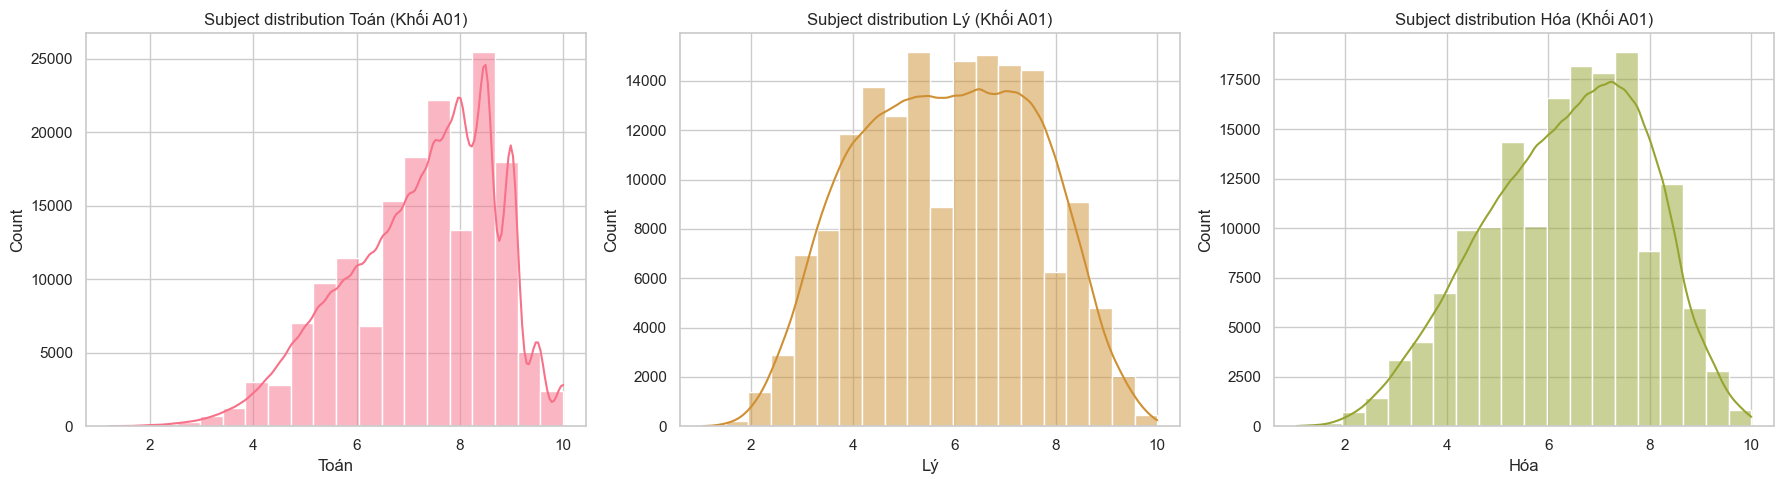

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
subjects_A00 = ['Toán', 'Lý', 'Hóa']
for i, subject in enumerate(subjects_A00):
    sns.histplot(df_A00[subject], bins=20, kde=True, ax=axes[i], color=sns.color_palette("husl", 8)[i])
    axes[i].set_title(f'Subject distribution {subject} (Khối A01)')
plt.tight_layout()
plt.show()

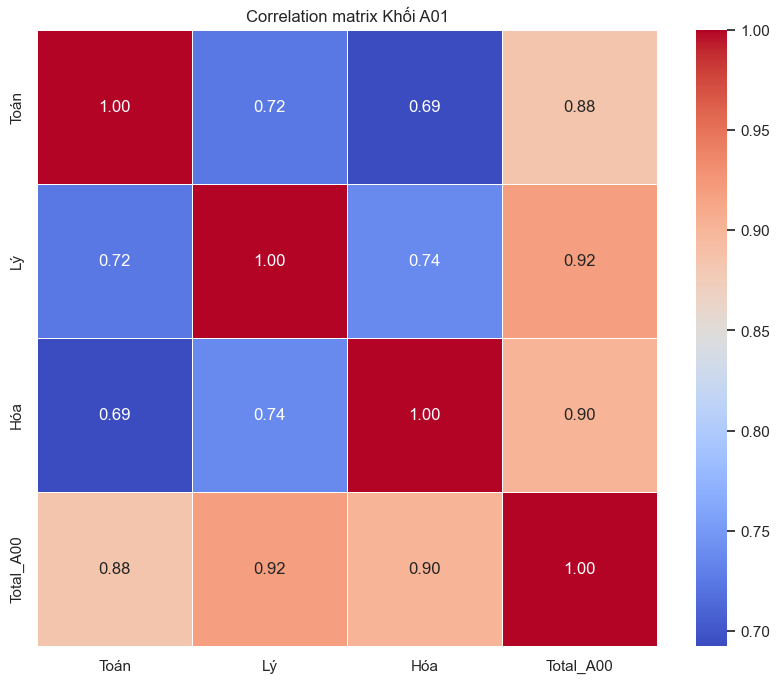

In [6]:
# Xem tương quan giữa các môn học. Nếu Toán và môn xã hội tương quan mạnh -> Bất thường!
plt.figure(figsize=(10, 8))
correlation_matrix = df_A00[['Toán', 'Lý', 'Hóa', 'Total_A00']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation matrix Khối A01')
plt.show()


Drawing score distribution for 36 blocks...


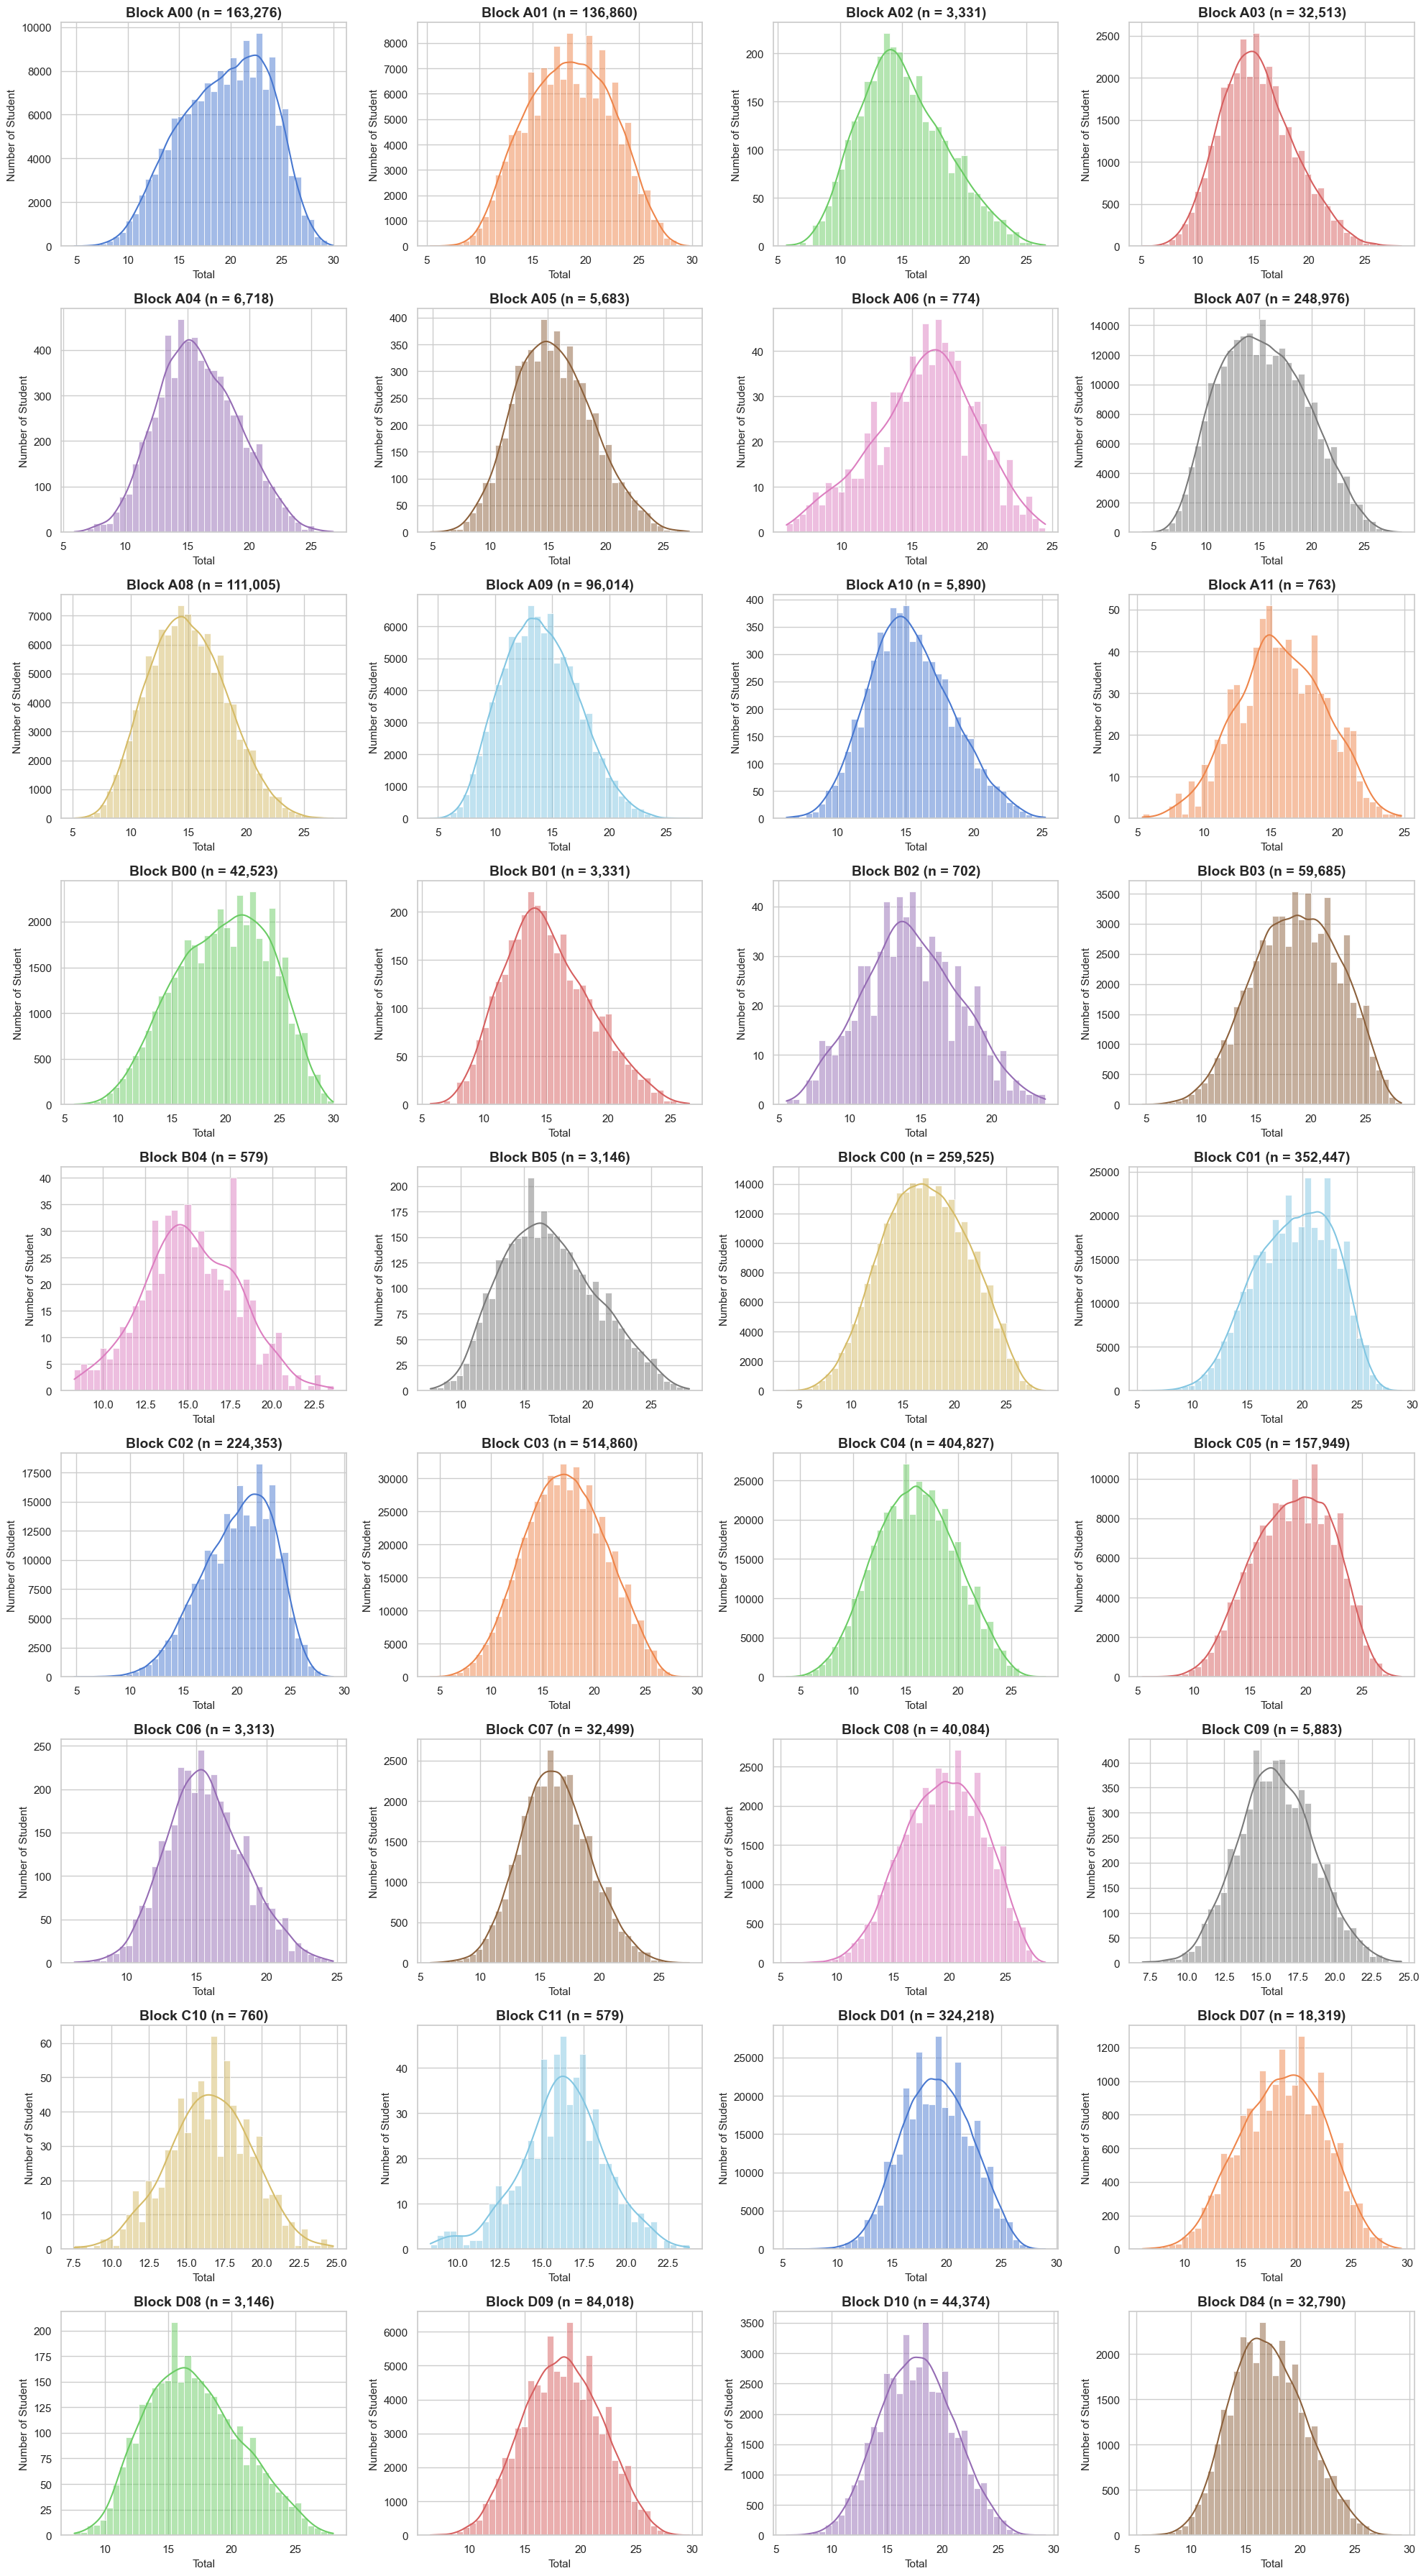

In [9]:
valid_blocks = list(dict_blocks.keys())
n_blocks = len(valid_blocks)
print(f"Drawing score distribution for {n_blocks} blocks...")
cols = 4  
rows = math.ceil(n_blocks / cols)
fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten() # Duỗi lưới ra thành mảng 1 chiều để dễ vòng lặp
sns.set_theme(style="whitegrid")
for i, block_name in enumerate(valid_blocks):
    df_block = dict_blocks[block_name]
    total_col = f'Total_{block_name}'
    
    sns.histplot(df_block[total_col], bins=40, kde=True, ax=axes[i], color=sns.color_palette("muted")[i % 10])
    
    axes[i].set_title(f'Block {block_name} (n = {len(df_block):,})', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Total', fontsize=11)
    axes[i].set_ylabel('Number of Student', fontsize=11)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

Drawing score distribution for 11 subjects...


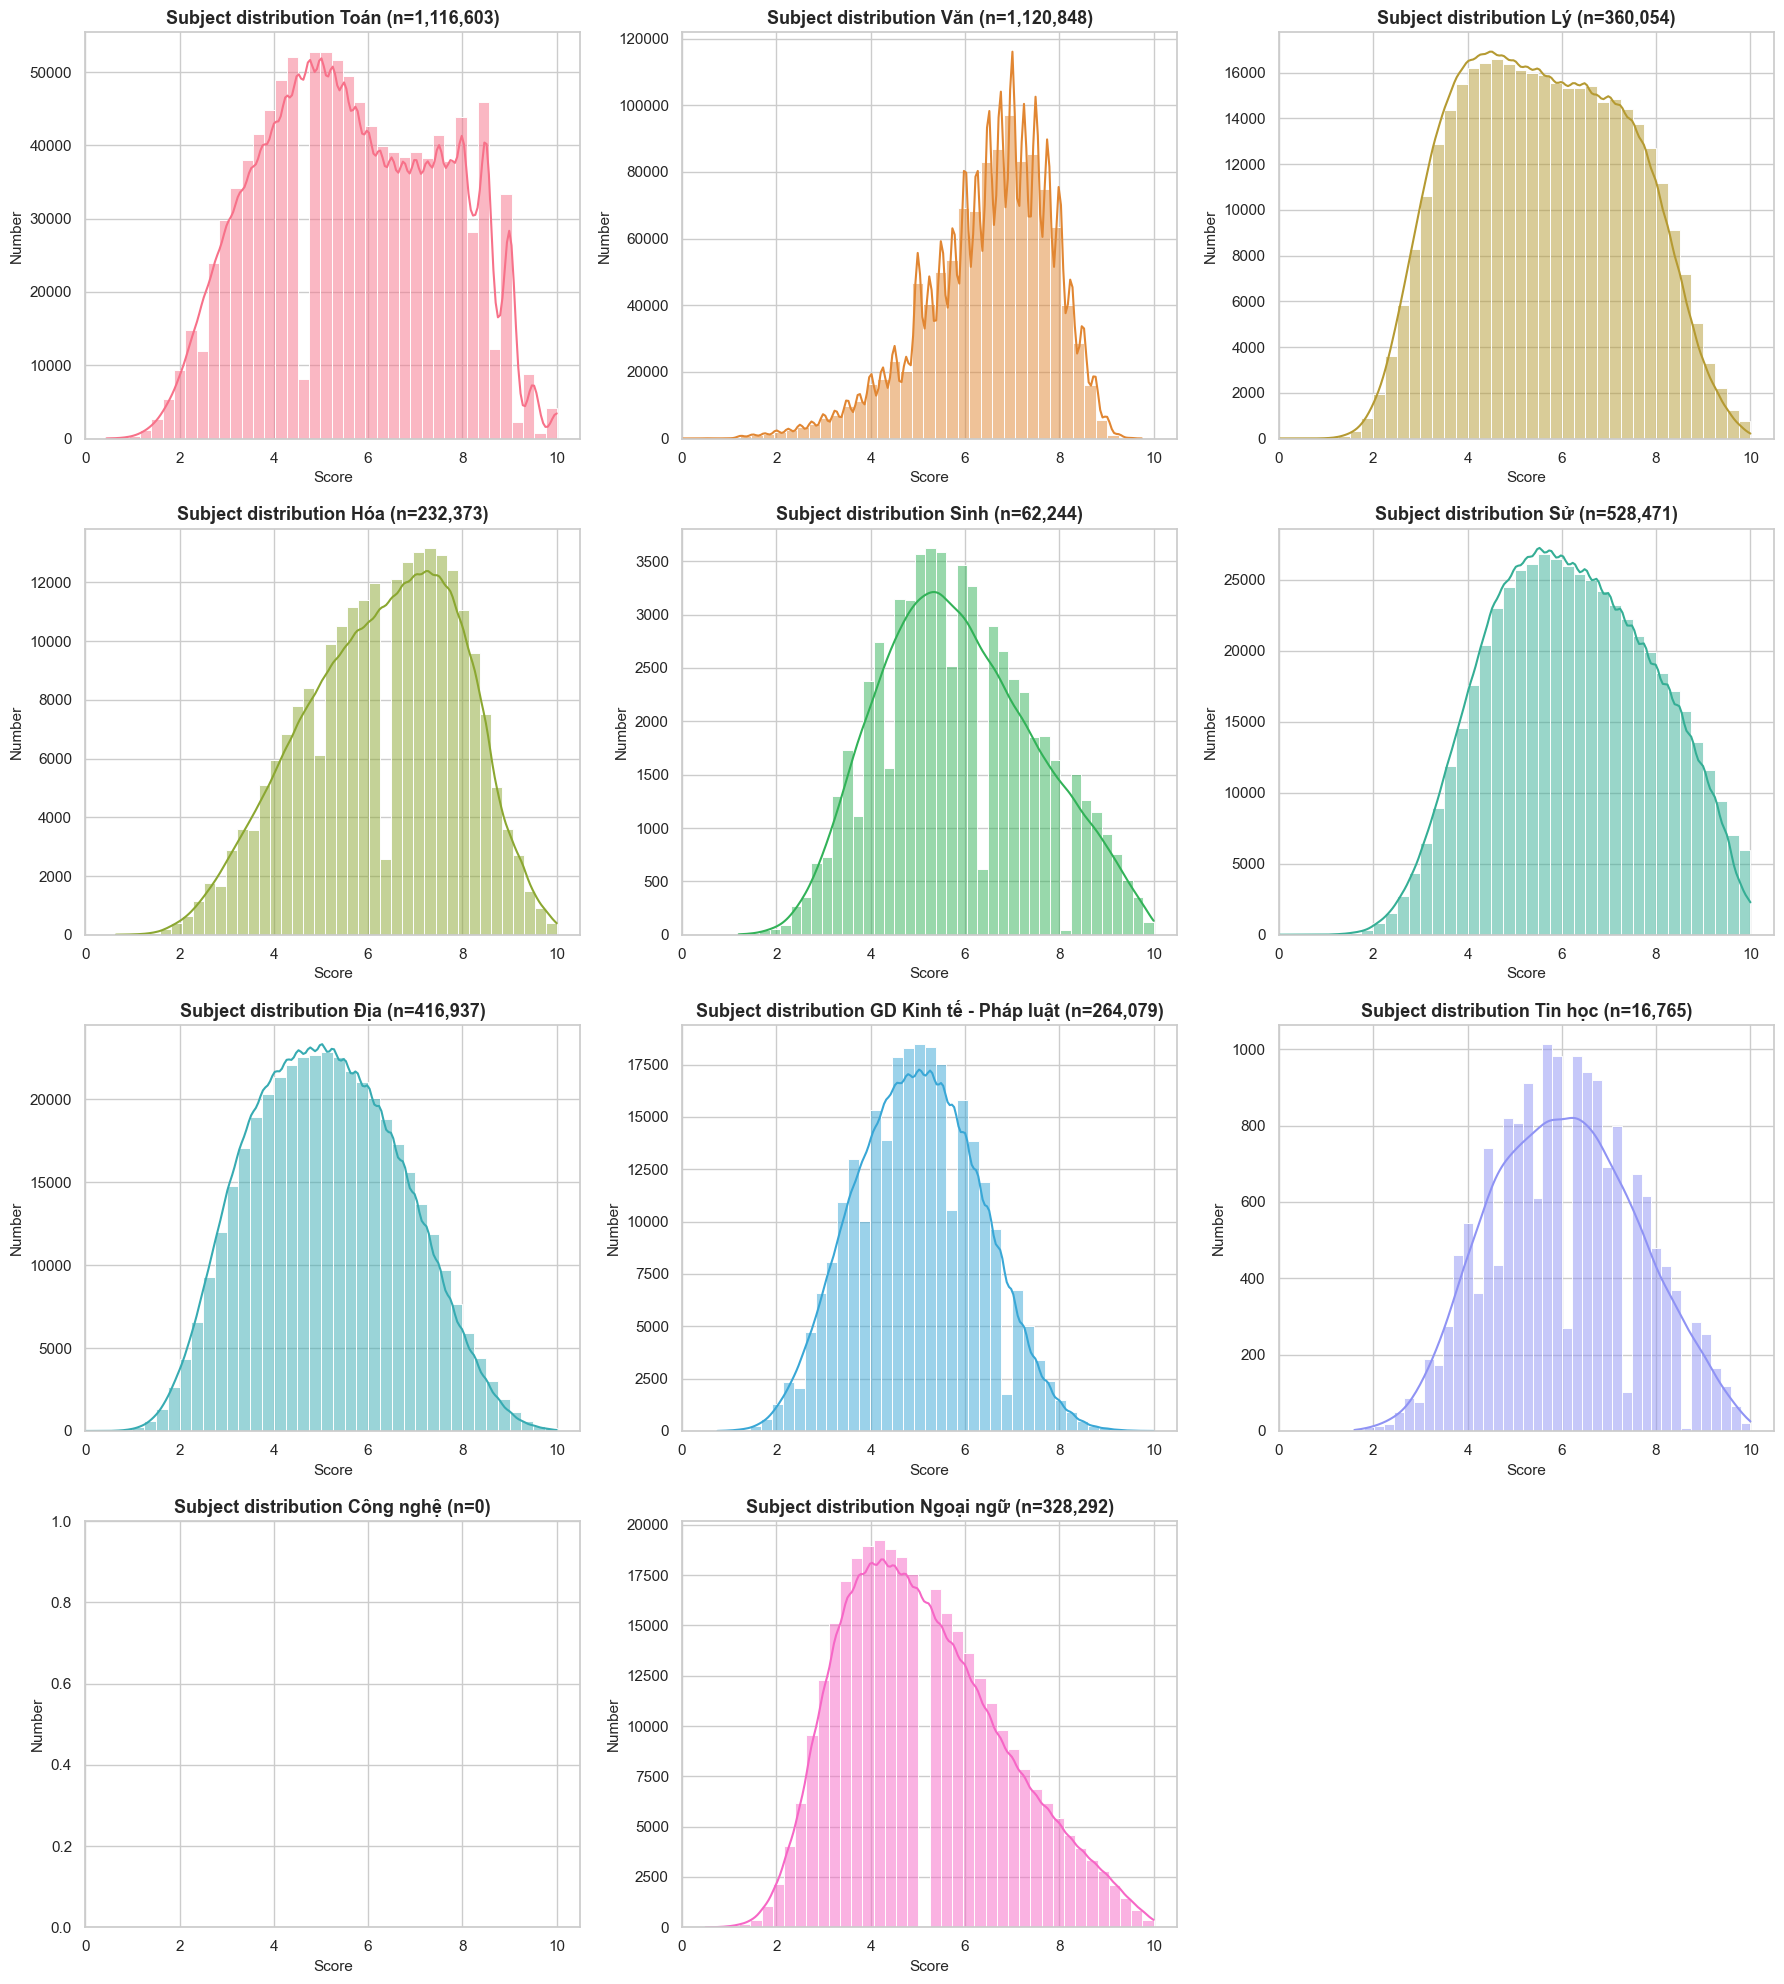

In [14]:
subjects = cleaner.subjects
print(f"Drawing score distribution for {len(subjects)} subjects...")
cols = 3 
rows = math.ceil(len(subjects) / cols)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()
colors = sns.color_palette("husl", len(subjects))
for i, subject in enumerate(subjects):
    valid_scores = df_flagged[subject].dropna()
    
    sns.histplot(valid_scores, bins=40,kde=True, ax=axes[i], color=colors[i], stat='count')
    
    # Trang trí
    axes[i].set_title(f'Subject distribution {subject} (n={len(valid_scores):,})', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Score', fontsize=11)
    axes[i].set_ylabel('Number', fontsize=11)
    
    axes[i].set_xlim(0, 10.5)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()